In [0]:
from pyspark.sql.functions import col
appointments_data = [
 (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
 (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
 (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
 (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
 (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
 (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
 (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
 (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
 (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
 (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
 (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
 (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
 (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
 (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
 (1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
 "appointment_id",
 "city",
 "department",
 "hospital",
 "consultation_fee",
 "status"
]
df = spark.createDataFrame(appointments_data, columns)
display(df)


appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


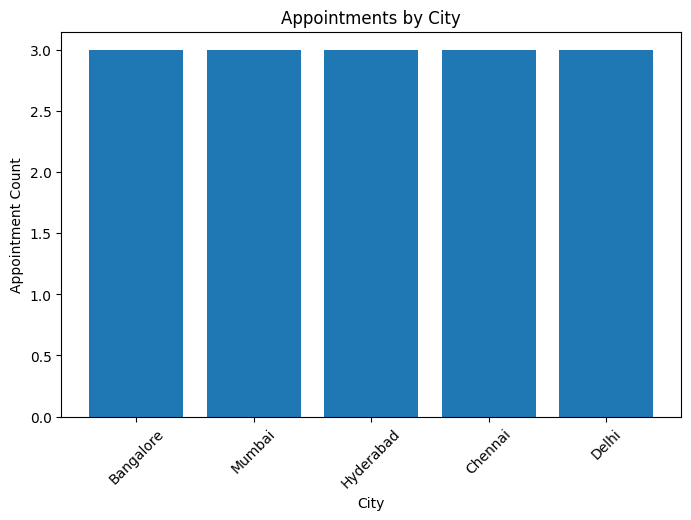

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum

city_count_df = df.groupBy("city").count()
city_pd = city_count_df.toPandas()
plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["count"])
plt.xlabel("City")
plt.ylabel("Appointment Count")
plt.title("Appointments by City")
plt.xticks(rotation=45)
plt.show()

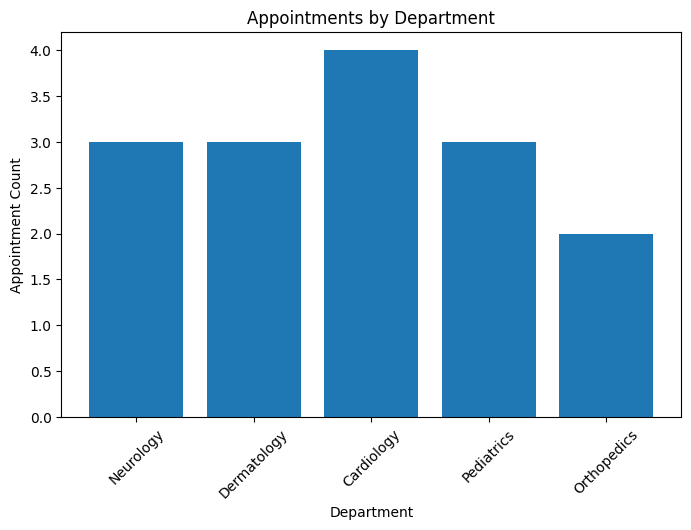

In [0]:
dept_count_df = df.groupBy("department").count()
dept_pd = dept_count_df.toPandas()
plt.figure(figsize=(8,5))
plt.bar(dept_pd["department"], dept_pd["count"])
plt.xlabel("Department")
plt.ylabel("Appointment Count")
plt.title("Appointments by Department")
plt.xticks(rotation=45)
plt.show()

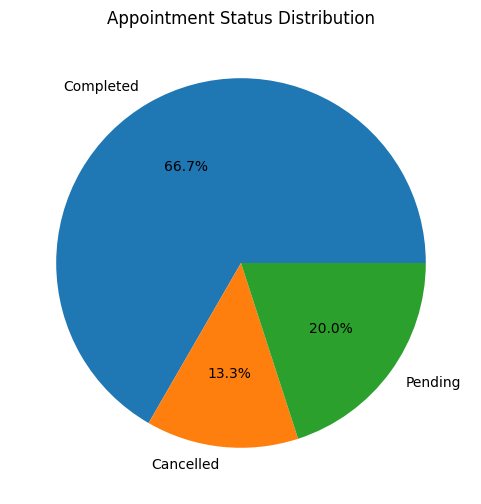

In [0]:
status_df = df.groupBy("status").count()
status_pd = status_df.toPandas()
plt.figure(figsize=(6,6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.show()

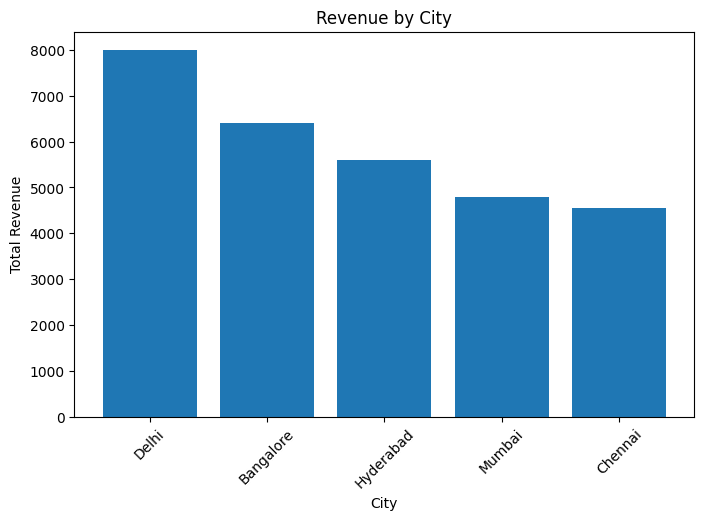

In [0]:
city_revenue_df = df.groupBy("city").agg(
    sum("consultation_fee").alias("total_revenue")
).orderBy(col("total_revenue").desc())
city_pd = city_revenue_df.toPandas()
plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

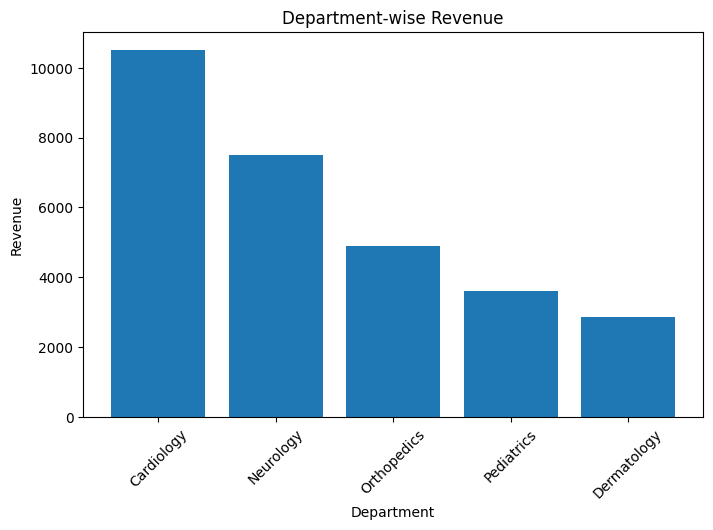

In [0]:
dept_revenue_df = df.groupBy("department").agg(
    sum("consultation_fee").alias("total_revenue")
).orderBy(col("total_revenue").desc())
dept_pd = dept_revenue_df.toPandas()
plt.figure(figsize=(8,5))
plt.bar(dept_pd["department"], dept_pd["total_revenue"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Department-wise Revenue")
plt.xticks(rotation=45)
plt.show()

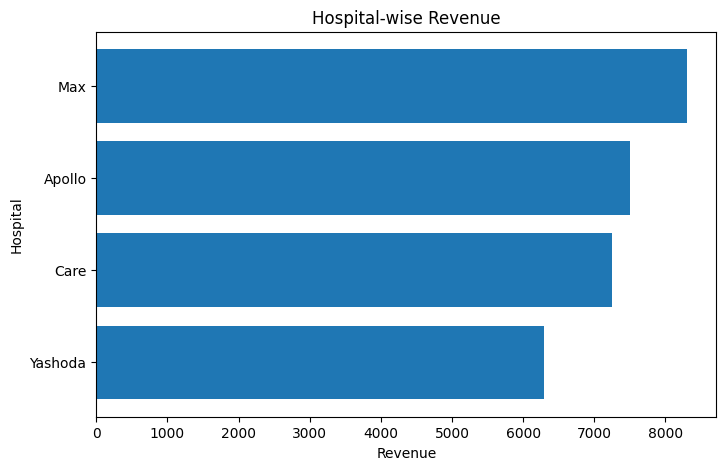

In [0]:
hospital_df = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("total_revenue")
).orderBy(col("total_revenue").desc())
hospital_pd = hospital_df.toPandas()
plt.figure(figsize=(8,5))
plt.barh(
    hospital_pd["hospital"],
    hospital_pd["total_revenue"]
)
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.title("Hospital-wise Revenue")
plt.gca().invert_yaxis()
plt.show()

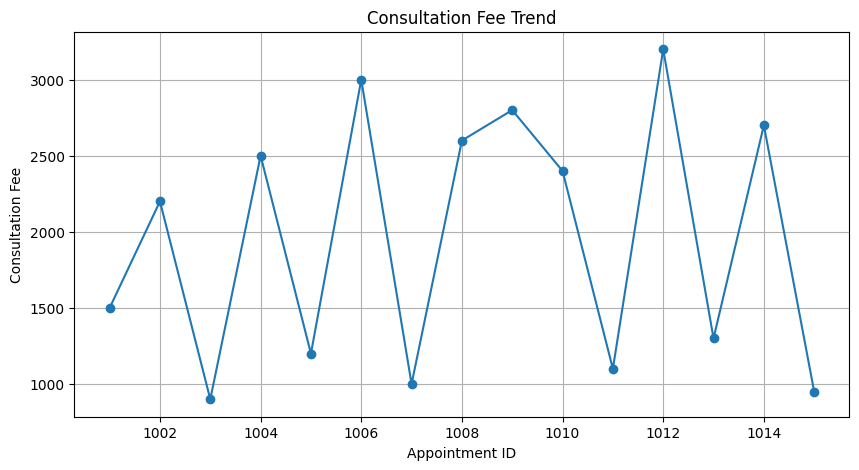

In [0]:
fee_df = df.select(
    "appointment_id",
    "consultation_fee"
).orderBy("appointment_id")
fee_pd = fee_df.toPandas()
plt.figure(figsize=(10,5))
plt.plot(
    fee_pd["appointment_id"],
    fee_pd["consultation_fee"],
    marker="o"
)
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Consultation Fee Trend")
plt.grid(True)
plt.show()

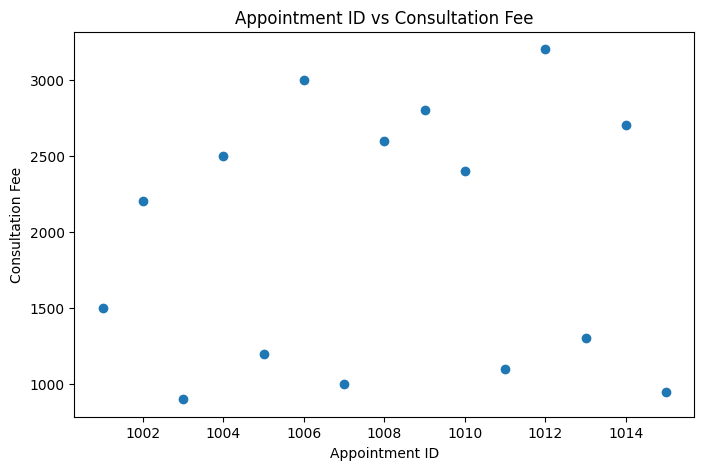

In [0]:
scatter_df = df.select(
    "appointment_id",
    "consultation_fee"
)
scatter_pd = scatter_df.toPandas()
plt.figure(figsize=(8,5))
plt.scatter(
    scatter_pd["appointment_id"],
    scatter_pd["consultation_fee"]
)
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Appointment ID vs Consultation Fee")
plt.show()

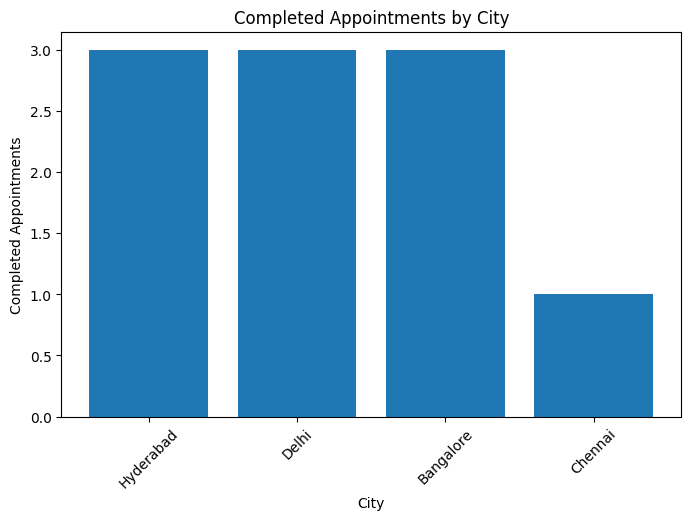

In [0]:
completed_df = df.filter(
    col("status") == "Completed"
).groupBy("city").count()
completed_pd = completed_df.toPandas()
plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["city"],
    completed_pd["count"]
)
plt.xlabel("City")
plt.ylabel("Completed Appointments")
plt.title("Completed Appointments by City")
plt.xticks(rotation=45)
plt.show()

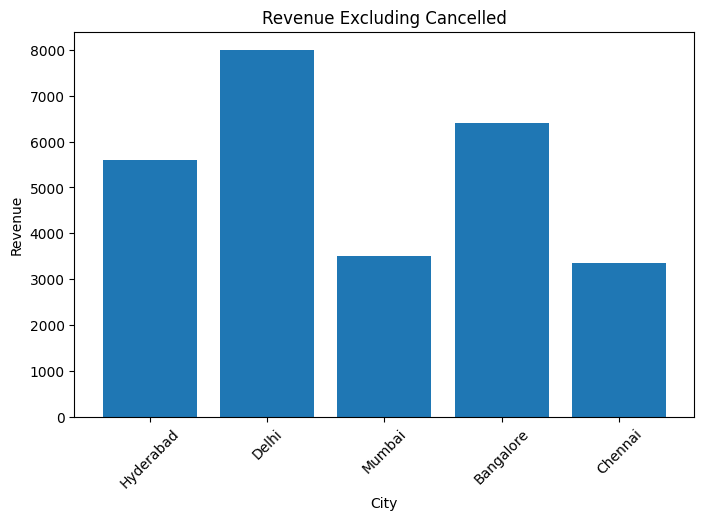

In [0]:
revenue_df = df.filter(
    col("status") != "Cancelled"
).groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
)
revenue_pd = revenue_df.toPandas()
plt.figure(figsize=(8,5))
plt.bar(
    revenue_pd["city"],
    revenue_pd["revenue"]
)
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue Excluding Cancelled")
plt.xticks(rotation=45)
plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

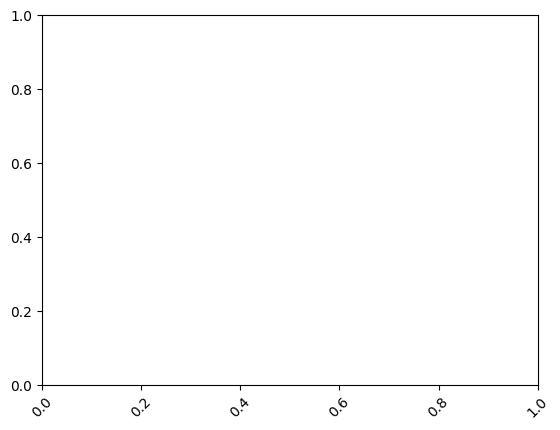

In [0]:
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Hospital Appointment Analysis')

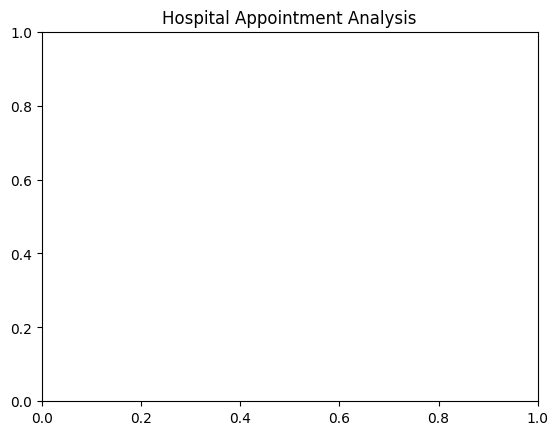

In [0]:
plt.title("Hospital Appointment Analysis")

Text(0.5, 0, 'City')

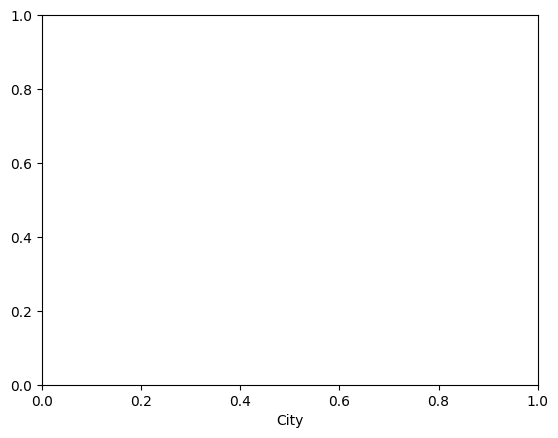

In [0]:
plt.xlabel("City")

Text(0, 0.5, 'Revenue')

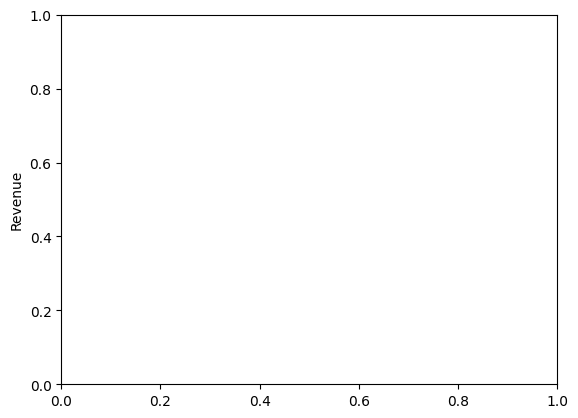

In [0]:
plt.ylabel("Revenue")

In [0]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [0]:
top_city_df = df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(
    col("revenue").desc()
).limit(3)

display(top_city_df)

city,revenue
Delhi,8000
Bangalore,6400
Hyderabad,5600


In [0]:
top_dept_df = df.groupBy("department").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(
    col("revenue").desc()
).limit(3)

display(top_dept_df)

department,revenue
Cardiology,10500
Neurology,7500
Orthopedics,4900


In [0]:
lowest_hospital_df = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(
    col("revenue")
).limit(1)

display(lowest_hospital_df)

hospital,revenue
Yashoda,6300


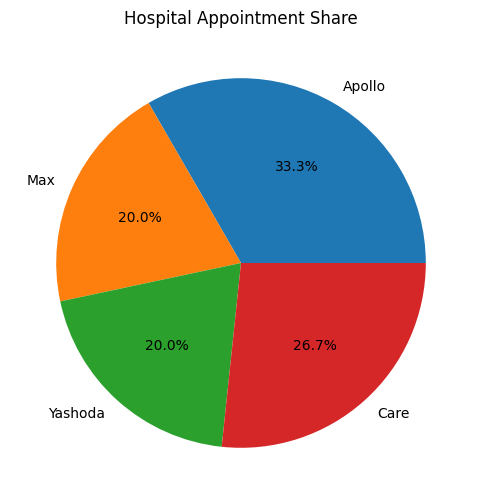

In [0]:
hospital_share_df = df.groupBy("hospital").count()

hospital_pd = hospital_share_df.toPandas()

plt.figure(figsize=(6,6))

plt.pie(
    hospital_pd["count"],
    labels=hospital_pd["hospital"],
    autopct="%1.1f%%"
)

plt.title("Hospital Appointment Share")
plt.show()

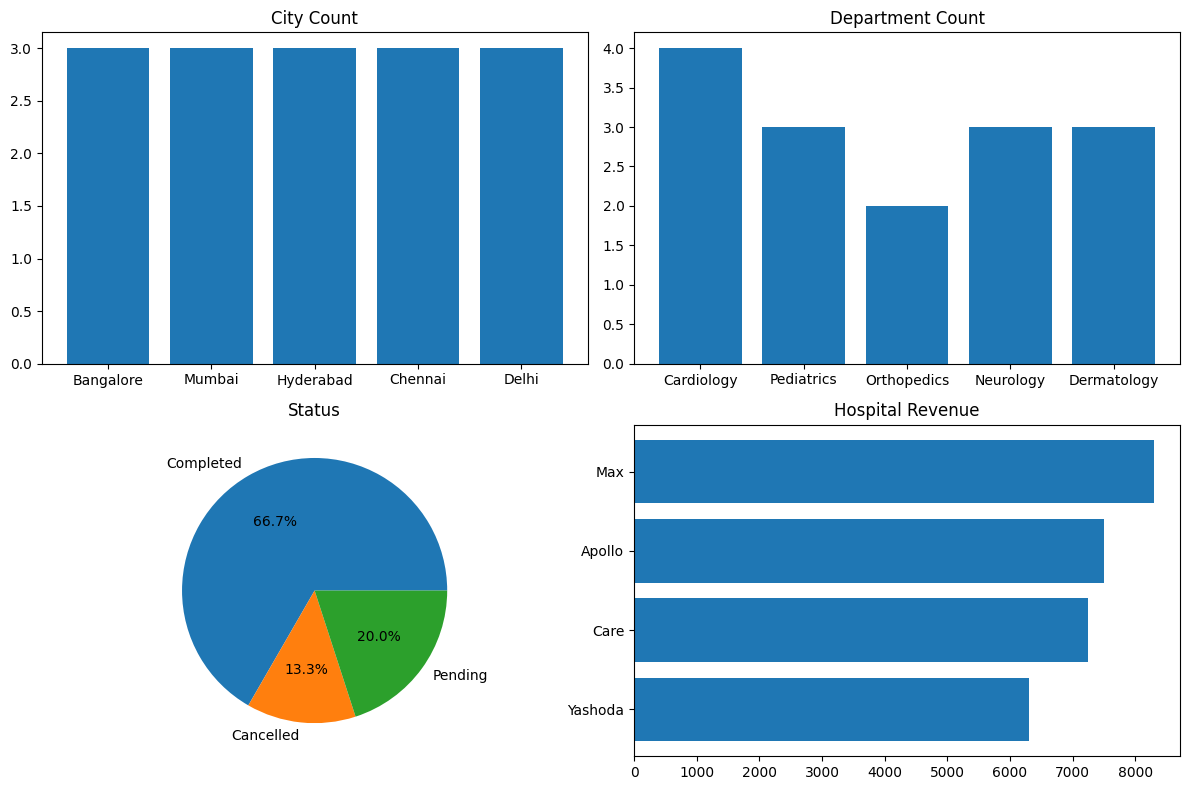

In [0]:
fig, axes = plt.subplots(2,2, figsize=(12,8))


city = df.groupBy("city").count().toPandas()

axes[0,0].bar(city["city"], city["count"])
axes[0,0].set_title("City Count")


dept = df.groupBy("department").count().toPandas()

axes[0,1].bar(dept["department"], dept["count"])
axes[0,1].set_title("Department Count")
status = df.groupBy("status").count().toPandas()
axes[1,0].pie(
    status["count"],
    labels=status["status"],
    autopct="%1.1f%%"
)
axes[1,0].set_title("Status")

hospital = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()
axes[1,1].barh(
    hospital["hospital"],
    hospital["revenue"]
)
axes[1,1].set_title("Hospital Revenue")
plt.tight_layout()
plt.show()